## 1. Configuración e Importación de Librerías
Primero, cargamos las herramientas necesarias. Como estamos en un entorno ROCm, verificaremos la GPU al inicio por pura higiene de ingeniería.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Verificación de hardware AMD
print(f"¿GPU AMD (ROCm) disponible?: {torch.cuda.is_available()}")

# Configuración estética para la memoria del TFM
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

¿GPU AMD (ROCm) disponible?: True


## 2. Carga y Limpieza Inicial
El dataset de Diabetes (130-US Hospitals) suele representar los valores nulos con un símbolo ?. Debemos tratar esto para cumplir con tu objetivo de tratamiento de valores nulos.

In [2]:
# Carga del dataset (ajusta el nombre del archivo si es necesario)
df = pd.read_csv('/compartida/data/diabetic_data.csv')

# Reemplazar '?' por NaN para que Pandas los reconozca
df.replace('?', np.nan, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Valores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Dimensiones del dataset: (101766, 50)
Valores nulos por columna:
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


## 3. Análisis de Cardinalidad
Uno de tus hitos técnicos es gestionar variables categóricas de alta cardinalidad. Vamos a identificarlas automáticamente.

--- Análisis de Cardinalidad ---
diag_3                      789
diag_2                      748
diag_1                      716
medical_specialty            72
payer_code                   17
age                          10
weight                        9
race                          5
glyburide-metformin           4
repaglinide                   4
metformin                     4
chlorpropamide                4
nateglinide                   4
pioglitazone                  4
glyburide                     4
glimepiride                   4
glipizide                     4
insulin                       4
miglitol                      4
acarbose                      4
rosiglitazone                 4
gender                        3
tolazamide                    3
A1Cresult                     3
max_glu_serum                 3
readmitted                    3
acetohexamide                 2
tolbutamide                   2
troglitazone                  2
metformin-rosiglitazone       2
metform

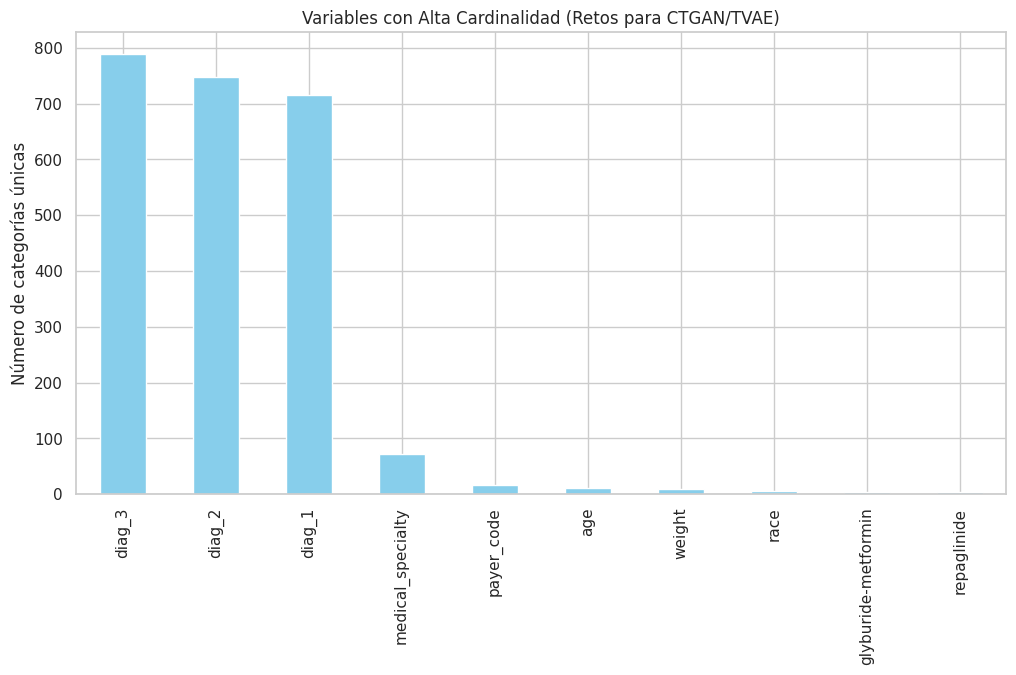

In [3]:
# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Calcular valores únicos por categoría
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

print("--- Análisis de Cardinalidad ---")
print(cardinality)

# Visualización de las Top 10 con más categorías
cardinality.head(10).plot(kind='bar', color='skyblue')
plt.title("Variables con Alta Cardinalidad (Retos para CTGAN/TVAE)")
plt.ylabel("Número de categorías únicas")
plt.show()

## 4. Análisis de Correlación (Fidelidad Estadística)
Para asegurar que los datos sintéticos conserven las interdependencias multivariantes (ej. relación entre edad y diagnósticos), primero debemos mapear las del dataset real.

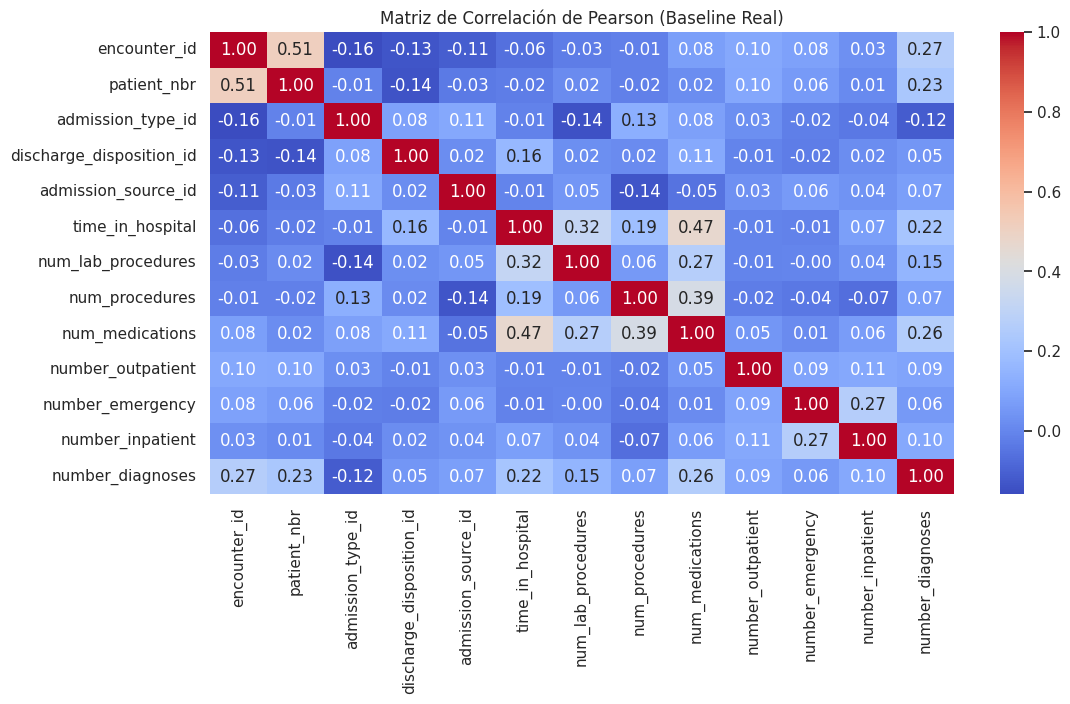

In [4]:
# Seleccionamos numéricas para Pearson (como propusiste en el punto 2.C)
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de Pearson (Baseline Real)")
plt.show()

## 5. Distribuciones Multimodales y Sesgadas
Tu TFM menciona la necesidad de manejar distribuciones multimodales y normalización de variables sesgadas. Visualicemos una variable crítica como `time_in_hospital`.

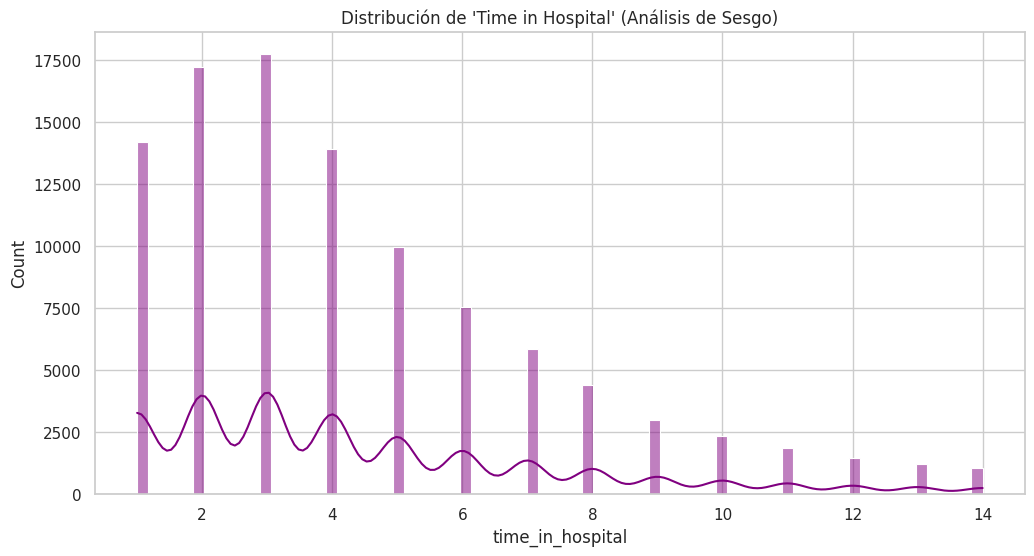

In [5]:
sns.histplot(df['time_in_hospital'], kde=True, color='purple')
plt.title("Distribución de 'Time in Hospital' (Análisis de Sesgo)")
plt.show()